In [1]:
import os
import xarray as xr
from glob import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from utils import vert_interp
from shared_read_HBR import *
from matplotlib import rcParams
from matplotlib.patches import Patch
from string import ascii_lowercase

site = 'HBR'
prefix = '20250913'
suffix = ''

rcParams['font.size'] = 16
rcParams['axes.titlesize'] = 16

elm_interface = np.array([0, 1.75, 4.51, 9.06, 16.55, 28.91, 49.29, 82.89, 138.28])
elm_nodes = (elm_interface[1:] + elm_interface[:-1]) * 0.5
elm_thickness = np.diff(elm_interface)
if site == 'HBR':
    nlevsoi = 8
else:
    nlevsoi = 10

In [2]:
################################################
# Read all simulated data
################################################

# actual run
flist = [os.path.join(os.environ['E3SM_ROOT'], 'output', 
                     f'{prefix}_HBR_ICB20TRCNPRDCTCBC_{suffix}erw', 'run', 
                     f'{prefix}_HBR_ICB20TRCNPRDCTCBC_{suffix}erw.elm.h1.{yy}-01-01-00000.nc') \
         for yy in range(1980, 2022)]

# reference run
flist_ctrl = [os.path.join(os.environ['E3SM_ROOT'], 'output', 
         f'20250720_HBR_ICB20TRCNPRDCTCBC_appCtrlerw', 'run', 
         f'20250720_HBR_ICB20TRCNPRDCTCBC_appCtrlerw.elm.h1.{yy}-01-01-00000.nc') \
            for yy in range(1980, 2022)]

hr = xr.open_mfdataset(flist)
hr_ctrl = xr.open_mfdataset(flist_ctrl)
tvec = pd.DatetimeIndex([pd.Timestamp(year=t.year, month=t.month, day=t.day)
                         for t in hr['time'].to_index()])

# meteorological variables
met_sim = pd.DataFrame({
    'rain': hr['RAIN'][:, 0] * 86400,
    'snow': hr['SNOW'][:, 0] * 86400, 
    'tair': hr['TBOT'][:, 0] - 273.15,
    'et': (hr['QVEGE'] + hr['QVEGT'] + hr['QSOIL'])[:, 0]*86400,
    'runoff': (hr['QRUNOFF'][:, 0] + hr['QDRAI'][:, 0]) * 86400,
    'tsoil': (np.matmul(hr['TSOI'][:, :6, 0].values,
                        hr['levgrnd'][:6].values.reshape(-1,1)) / \
              np.sum(hr['levgrnd'][:6].values) - 273.15)[:,0], # average TSOIL of 30cm
    'theta': (np.matmul(hr['H2OSOI'][:, :6, 0].values,
                        hr['levgrnd'][:6].values.reshape(-1,1)) / \
              np.sum(hr['levgrnd'][:6].values))[:,0], # average soil water content of 30cm
    'srad': hr['FSDS'][:, 0], 
    'zwt': hr['ZWT'][:, 0], 
    'zwt_perch': hr['ZWT_PERCH'][:,0],
    'qrunoff': hr['QRUNOFF'][:, 0] * 86400, 
    'qdrai_perch': hr['QDRAI_PERCH'][:, 0] * 86400, 
    'qdrai': hr['QDRAI'][:, 0] * 86400, 
    'qover': hr['QOVER'][:, 0] * 86400, 
    'qexfl': hr['QEXFL'][:, 0] * 86400, 
    'qout': hr['QOUT_EXTERNAL'][:, :, 0].sum(axis = 1, keepdims = False) * 86400
}, index = tvec[:])

In [3]:
################################################
# Collect observed ecohydrological variables
################################################

# (1) SWE
swe_obs = read_snowcourse()
swe_obs.loc[swe_obs < 0] = np.nan
swe_sim = pd.Series(hr['H2OSNO'][:, 0], index = tvec[:])

overlap = pd.date_range('2012-01-01', '2021-12-31', freq = '1D')
swe_obs = swe_obs.reindex(overlap)
swe_sim = swe_sim.reindex(overlap)

# drop Feb 29
swe_obs = swe_obs.loc[~((swe_obs.index.month == 2) & (swe_obs.index.day == 29))]
swe_sim = swe_sim.loc[~((swe_sim.index.month == 2) & (swe_sim.index.day == 29))]

# (2) annual maximum LAI
lai_obs = read_lai()
lai_obs_mean = lai_obs.groupby('Year').mean().iloc[:,0]
lai_obs_std = lai_obs.groupby('Year').std().iloc[:,0]

lai_sim = pd.Series(hr['TLAI'][:, 0], index = tvec[:])
lai_sim_mean = lai_sim.resample('1Y').max()

common_years = lai_obs_mean.index.intersection(lai_sim_mean.index.year)
common_years = common_years[(common_years >= 2012) & (common_years <= 2019)]
lai_obs_mean = lai_obs_mean.loc[common_years]
lai_obs_std = lai_obs_std.loc[common_years]
lai_sim_mean = lai_sim_mean.loc[lai_sim_mean.index.year.isin(common_years)]
lai_sim_mean.index = lai_sim_mean.index.year

# (3) Runoff
runoff_obs = read_runoff() # mm/day
runoff_obs = runoff_obs.loc[(runoff_obs.index.year >= 2012) & (runoff_obs.index.year <= 2022)]
runoff_obs = runoff_obs.loc[(runoff_obs.index.month != 2) | (runoff_obs.index.day != 29)]
runoff_sim = pd.Series(
    (hr['QRUNOFF'][:, 0]) * 86400,  # hr['QRUNOFF'][:, 0] 
    index = tvec[:]
)
runoff_sim = runoff_sim.loc[runoff_sim.index >= runoff_obs.index[0]]

et_sim = pd.Series(
   (hr['QVEGE'] + hr['QVEGT'] + hr['QSOIL'])[:, 0]*86400,
    index = tvec[:]
)

common_index = runoff_obs.index.intersection(runoff_sim.index)
runoff_obs = runoff_obs.loc[common_index]
runoff_sim = runoff_sim.loc[common_index]
et_sim = et_sim.loc[common_index]

/autofs/nccsopen-svm1_home/ywo/Git/erw_scripts/shared_read_HBR.py:52: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'data',
/tmp/ipykernel_4164145/1178248915.py:24: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  lai_sim_mean = lai_sim.resample('1Y').max()


In [4]:
################################################
# Use the unit hydrograph method to route the simulated runoff
################################################
from scipy.signal import fftconvolve
from scipy.optimize import minimize_scalar, minimize

def derive_unit_hydrograph(P, Q, uh_length=None, method='wiener', regularization=1e-3):
    """
    Derive unit hydrograph from observed precipitation and streamflow.
    
    Parameters:
    -----------
    P : array-like or pandas Series
        Precipitation or effective rainfall (mm/day)
    Q : array-like or pandas Series
        Observed streamflow (mm/day)
    uh_length : int, optional
        Length of unit hydrograph (timesteps). Default: min(30, len(P)//4)
    method : str
        'wiener' - Wiener deconvolution (frequency domain, fast)
        'lstsq' - Least squares (time domain, more stable)
    regularization : float
        Regularization parameter to stabilize deconvolution
    
    Returns:
    --------
    uh : numpy array
        Unit hydrograph ordinates (normalized to sum to 1)
    """
    P = np.asarray(P, dtype=float)
    Q = np.asarray(Q, dtype=float)
    
    if uh_length is None:
        uh_length = min(30, len(P) // 4)
    
    if method == 'wiener':
        # Frequency domain deconvolution
        n = len(P)
        P_fft = np.fft.fft(P, n=n + uh_length)
        Q_fft = np.fft.fft(Q, n=n + uh_length)
        
        # Wiener deconvolution with regularization
        H_fft = Q_fft * np.conj(P_fft) / (np.abs(P_fft)**2 + regularization)
        uh = np.fft.ifft(H_fft).real[:uh_length]
        
    elif method == 'lstsq':
        # Build convolution matrix
        n = len(P)
        A = np.zeros((n, uh_length))
        for i in range(uh_length):
            A[i:, i] = P[:n-i]
        
        # Regularized least squares
        ATA = A.T @ A + regularization * np.eye(uh_length)
        ATQ = A.T @ Q
        uh = np.linalg.solve(ATA, ATQ)
    
    else:
        raise ValueError("method must be 'wiener' or 'lstsq'")
    
    # Enforce non-negativity and normalize
    uh = np.maximum(uh, 0)
    if uh.sum() > 0:
        uh = uh / uh.sum()
    
    return uh


def parametric_unit_hydrograph(length, peak_time, shape='gamma'):
    """
    Generate parametric unit hydrograph.
    
    Parameters:
    -----------
    length : int
        Length of unit hydrograph (timesteps)
    peak_time : float
        Time to peak (timesteps)
    shape : str
        'gamma' - Gamma distribution (Nash cascade)
        'triangle' - Triangular unit hydrograph
        'scs' - SCS dimensionless unit hydrograph
    
    Returns:
    --------
    uh : numpy array
        Unit hydrograph ordinates (normalized)
    """
    t = np.arange(1, length + 1)
    
    if shape == 'gamma':
        # Nash cascade: n reservoirs in series
        # peak_time ≈ (n-1) * k, using n=3 as typical
        n = 3
        k = peak_time / (n - 1) if n > 1 else peak_time
        from scipy.special import gamma as gamma_func
        uh = (t / k)**(n-1) * np.exp(-t / k) / (k * gamma_func(n))
        
    elif shape == 'triangle':
        tp = peak_time
        tb = 2.67 * tp  # base time
        uh = np.where(t <= tp, t / tp, np.maximum(0, 1 - (t - tp) / (tb - tp)))
        
    elif shape == 'scs':
        # SCS dimensionless UH approximation
        t_ratio = t / peak_time
        uh = np.where(t_ratio <= 1, 
                      t_ratio**3.5,
                      np.exp(-1.5 * (t_ratio - 1)))
    else:
        raise ValueError("shape must be 'gamma', 'triangle', or 'scs'")
    
    uh = np.maximum(uh, 0)
    return uh / uh.sum()


def route_with_uh(R, uh):
    """
    Route runoff using unit hydrograph convolution.
    Vectorized FFT-based convolution.
    
    Parameters:
    -----------
    R : array-like or pandas Series
        Runoff time series (mm/day)
    uh : array-like
        Unit hydrograph ordinates
    
    Returns:
    --------
    Q : numpy array or pandas Series
        Routed streamflow (mm/day)
    """
    is_series = isinstance(R, pd.Series)
    index = R.index if is_series else None
    R = np.asarray(R, dtype=float)
    uh = np.asarray(uh, dtype=float)
    
    # FFT convolution (much faster than np.convolve for large arrays)
    Q = fftconvolve(R, uh, mode='full')[:len(R)]
    
    if is_series:
        return pd.Series(Q, index=index)
    return Q


def calibrate_parametric_uh(R, Q_obs, length=30, shape='gamma', 
                            peak_range=(0.5, 10.0)):
    """
    Calibrate parametric unit hydrograph by optimizing peak time.
    
    Parameters:
    -----------
    R : array-like
        Runoff time series (mm/day)
    Q_obs : array-like
        Observed streamflow (mm/day)
    length : int
        UH length (timesteps)
    shape : str
        UH shape ('gamma', 'triangle', 'scs')
    peak_range : tuple
        Range of peak times to search
    
    Returns:
    --------
    best_uh : numpy array
        Calibrated unit hydrograph
    best_peak : float
        Optimal peak time
    best_nse : float
        NSE at optimal parameters
    """
    R = np.asarray(R)
    Q_obs = np.asarray(Q_obs)
    
    def objective(peak_time):
        uh = parametric_unit_hydrograph(length, peak_time, shape)
        Q_sim = route_with_uh(R, uh)
        nse = 1 - np.sum((Q_obs - Q_sim)**2) / np.sum((Q_obs - np.mean(Q_obs))**2)
        return -nse  # minimize negative NSE
    
    result = minimize_scalar(objective, bounds=peak_range, method='bounded')
    best_peak = result.x
    best_nse = -result.fun
    best_uh = parametric_unit_hydrograph(length, best_peak, shape)
    
    return best_uh, best_peak, best_nse


def extract_event_uh(P, Q, threshold_P=5.0, threshold_Q=None, 
                     min_gap=3, uh_length=20):
    """
    Extract unit hydrograph from isolated storm events.
    
    Parameters:
    -----------
    P : array-like or pandas Series
        Precipitation (mm/day)
    Q : array-like or pandas Series
        Streamflow (mm/day)
    threshold_P : float
        Minimum precipitation to identify event start
    threshold_Q : float, optional
        Minimum Q rise to confirm event. Default: 0.5 * std(Q)
    min_gap : int
        Minimum dry days between events
    uh_length : int
        Length of extracted UH
    
    Returns:
    --------
    uh : numpy array
        Averaged unit hydrograph from events
    events : list of dict
        Detected event information
    """
    P = np.asarray(P)
    Q = np.asarray(Q)
    n = len(P)
    
    if threshold_Q is None:
        threshold_Q = 0.5 * np.std(Q)
    
    # Find event starts
    events = []
    i = 0
    while i < n - uh_length:
        if P[i] >= threshold_P:
            # Check for isolated event (dry before)
            start_dry = max(0, i - min_gap)
            if np.max(P[start_dry:i]) < threshold_P / 2 or i < min_gap:
                # Find event end
                j = i + 1
                while j < min(i + min_gap + 5, n) and P[j] > 0.5:
                    j += 1
                
                # Extract response
                if i + uh_length <= n:
                    Q_event = Q[i:i + uh_length]
                    Q_base = Q[i]  # or interpolated baseflow
                    Q_rise = Q_event - Q_base
                    P_total = np.sum(P[i:j])
                    
                    if np.max(Q_rise) > threshold_Q and P_total > 0:
                        uh_event = Q_rise / P_total
                        uh_event = np.maximum(uh_event, 0)
                        events.append({
                            'start': i,
                            'P_total': P_total,
                            'Q_peak': np.max(Q_event),
                            'uh': uh_event
                        })
                i = j + min_gap
                continue
        i += 1
    
    if not events:
        raise ValueError("No suitable events found. Try adjusting thresholds.")
    
    # Average unit hydrographs (weighted by event size)
    weights = np.array([e['P_total'] for e in events])
    weights = weights / weights.sum()
    uh = np.sum([w * e['uh'] for w, e in zip(weights, events)], axis=0)
    uh = uh / uh.sum()
    
    return uh, events


"""# Example usage
if __name__ == "__main__":
    # Generate synthetic data
    np.random.seed(42)
    n = 365
    
    # Synthetic precipitation events
    P = np.zeros(n)
    event_days = [30, 75, 120, 180, 220, 280, 330]
    for d in event_days:
        P[d:d+2] = np.random.uniform(10, 30, 2)
    
    # True unit hydrograph
    uh_true = parametric_unit_hydrograph(15, peak_time=2.0, shape='gamma')
    
    # Synthetic runoff (simplified: R ≈ 0.4 * P for events)
    R = 0.4 * P
    
    # Generate observed Q
    Q_obs = route_with_uh(R, uh_true) + np.random.normal(0, 0.1, n)
    Q_obs = np.maximum(Q_obs, 0)
    
    print("="*50)
    print("Method 1: Derive UH from P and Q (deconvolution)")
    print("="*50)
    uh_derived = derive_unit_hydrograph(P, Q_obs, uh_length=15, method='lstsq')
    Q_sim1 = route_with_uh(R, uh_derived)
    nse1 = 1 - np.sum((Q_obs - Q_sim1)**2) / np.sum((Q_obs - np.mean(Q_obs))**2)
    print(f"NSE: {nse1:.3f}")
    
    print("\n" + "="*50)
    print("Method 2: Calibrate parametric UH")
    print("="*50)
    uh_calib, peak, nse2 = calibrate_parametric_uh(R, Q_obs, length=15, shape='gamma')
    print(f"Optimal peak time: {peak:.2f} days")
    print(f"NSE: {nse2:.3f}")
    
    print("\n" + "="*50)
    print("Method 3: Extract UH from isolated events")
    print("="*50)
    try:
        uh_events, events = extract_event_uh(P, Q_obs, threshold_P=8.0, uh_length=15)
        Q_sim3 = route_with_uh(R, uh_events)
        nse3 = 1 - np.sum((Q_obs - Q_sim3)**2) / np.sum((Q_obs - np.mean(Q_obs))**2)
        print(f"Events found: {len(events)}")
        print(f"NSE: {nse3:.3f}")
    except ValueError as e:
        print(f"Could not extract events: {e}")
"""

'# Example usage\nif __name__ == "__main__":\n    # Generate synthetic data\n    np.random.seed(42)\n    n = 365\n\n    # Synthetic precipitation events\n    P = np.zeros(n)\n    event_days = [30, 75, 120, 180, 220, 280, 330]\n    for d in event_days:\n        P[d:d+2] = np.random.uniform(10, 30, 2)\n\n    # True unit hydrograph\n    uh_true = parametric_unit_hydrograph(15, peak_time=2.0, shape=\'gamma\')\n\n    # Synthetic runoff (simplified: R ≈ 0.4 * P for events)\n    R = 0.4 * P\n\n    # Generate observed Q\n    Q_obs = route_with_uh(R, uh_true) + np.random.normal(0, 0.1, n)\n    Q_obs = np.maximum(Q_obs, 0)\n\n    print("="*50)\n    print("Method 1: Derive UH from P and Q (deconvolution)")\n    print("="*50)\n    uh_derived = derive_unit_hydrograph(P, Q_obs, uh_length=15, method=\'lstsq\')\n    Q_sim1 = route_with_uh(R, uh_derived)\n    nse1 = 1 - np.sum((Q_obs - Q_sim1)**2) / np.sum((Q_obs - np.mean(Q_obs))**2)\n    print(f"NSE: {nse1:.3f}")\n\n    print("\n" + "="*50)\n    prin

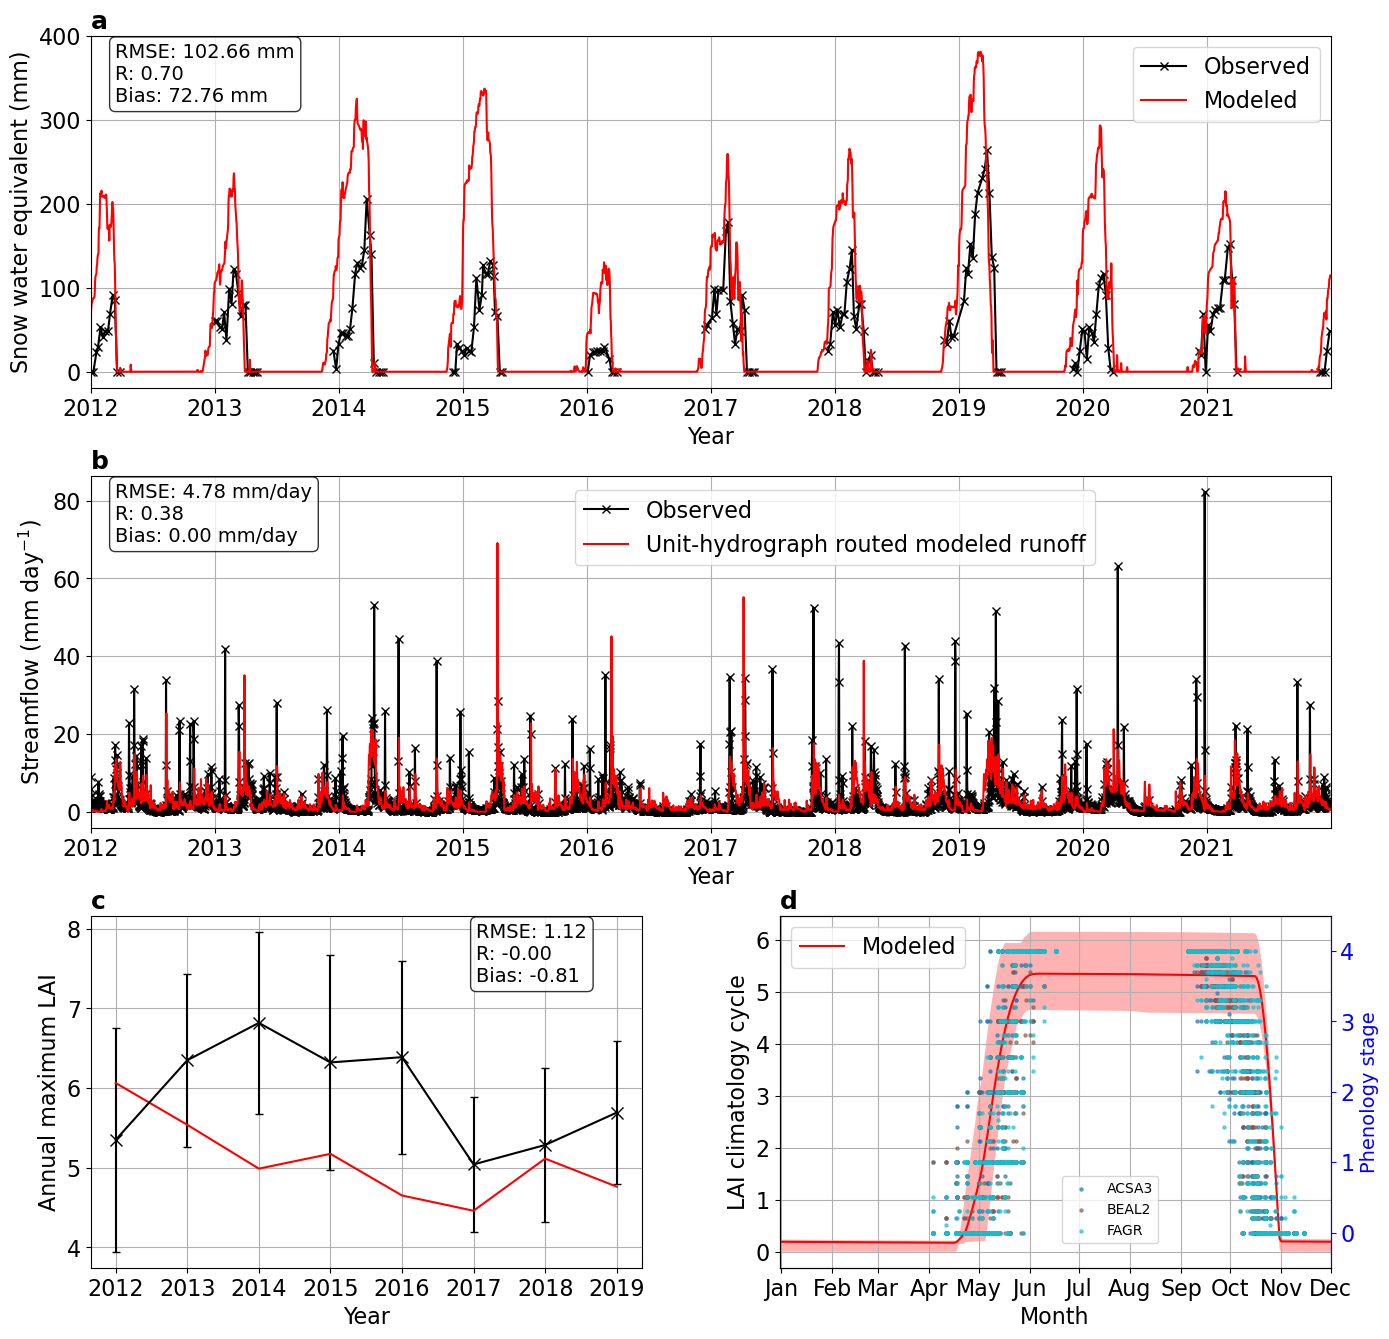

In [5]:
################################################
# Validation on observed ecohydrological data
################################################

fig = plt.figure(figsize=(16, 16))
gs = fig.add_gridspec(3, 2, hspace=0.25, wspace=0.25)

#########################
# Row 1: SWE (spanning 2 columns)
#########################
ax = fig.add_subplot(gs[0, :])

# Plot SWE observations with breaks across summers
# Remove NaN values first
swe_obs_valid = swe_obs[~np.isnan(swe_obs.values)]

# Identify winter segments based on time gaps (>90 days = summer break)
winter_segments = []
current_segment_idx = []
current_segment_vals = []

for i, (idx, val) in enumerate(swe_obs_valid.items()):
    if i == 0:
        # First measurement - start first segment
        current_segment_idx.append(idx)
        current_segment_vals.append(val)
    else:
        # Check time gap from previous measurement
        prev_idx = swe_obs_valid.index[i-1]
        time_gap = (idx - prev_idx).days
        
        if time_gap > 90:  # More than 3 months gap - summer break
            # Save current segment and start new one
            if len(current_segment_idx) > 0:
                winter_segments.append((current_segment_idx.copy(), current_segment_vals.copy()))
            current_segment_idx = [idx]
            current_segment_vals = [val]
        else:
            # Continue current segment
            current_segment_idx.append(idx)
            current_segment_vals.append(val)

# Don't forget the last segment
if len(current_segment_idx) > 0:
    winter_segments.append((current_segment_idx, current_segment_vals))

# Plot each winter segment separately
for i, (seg_idx, seg_vals) in enumerate(winter_segments):
    if i == 0:
        ax.plot(seg_idx, seg_vals, '-xk', label='Observed')
    else:
        ax.plot(seg_idx, seg_vals, '-xk')

ax.plot(swe_sim.index, swe_sim, '-r', label = 'Modeled')
ax.legend()
ax.set_xticks(pd.date_range('2012-01-01', '2022-01-01', freq = '1YS'))
ax.set_xticklabels(range(2012, 2023))
ax.set_xlim([pd.Timestamp('2012-01-01'), pd.Timestamp('2021-12-31')])
ax.grid(True)
ax.set_ylabel('Snow water equivalent (mm)')
ax.set_xlabel('Year')
# Calculate statistics
rmse_a = np.sqrt(np.nanmean((swe_obs.values - swe_sim.values)**2))
corr_a = np.corrcoef(swe_obs.values[~np.isnan(swe_obs.values)],
                     swe_sim.values[~np.isnan(swe_obs.values)])[0, 1]
bias_a = np.nanmean(swe_sim.values - swe_obs.values)
ax.text(0.02, 0.98, f'RMSE: {rmse_a:.2f} mm\nR: {corr_a:.2f}\nBias: {bias_a:.2f} mm',
        transform=ax.transAxes, va='top', fontsize=14,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.text(0., 1.02, 'a', transform = ax.transAxes, fontweight='bold', fontsize=18)

#########################
# Row 2: Daily runoff (spanning 2 columns)
#########################
ax = fig.add_subplot(gs[1, :])
ax.plot(runoff_obs.index, runoff_obs, '-xk', label = 'Observed')

# Derive UH from observations
# Route your modeled runoff
precip = (met_sim['rain'] + met_sim['snow']).loc[runoff_obs.index]
uh = derive_unit_hydrograph(precip, runoff_obs, uh_length=20, method='lstsq')
runoff_ma = route_with_uh(runoff_sim, uh)

ax.plot(runoff_ma.index, runoff_ma, '-r', label = 'Unit-hydrograph routed modeled runoff')
ax.legend(ncol = 1, loc='upper center', bbox_to_anchor = (0.6, 0.99))
#ax.set_yscale('symlog', linthresh = 1)
ax.set_ylabel('Streamflow (mm day$^{-1}$)')
ax.set_xlabel('Year')
ax.set_xticks(pd.date_range('2012-01-01', '2022-01-01', freq = '1YS'))
ax.set_xticklabels(range(2012, 2023))
ax.set_xlim([pd.Timestamp('2012-01-01'), pd.Timestamp('2021-12-31')])
ax.grid(True)
# Calculate statistics
rmse_b = np.sqrt(np.nanmean((runoff_obs.values - runoff_ma.values)**2))
corr_b = np.corrcoef(runoff_obs.values[~np.isnan(runoff_obs.values) & ~np.isnan(runoff_ma.values)],
                     runoff_ma.values[~np.isnan(runoff_obs.values) & ~np.isnan(runoff_ma.values)])[0, 1]
bias_b = np.nanmean(runoff_ma.values - runoff_ma.values)
ax.text(0.02, 0.98, f'RMSE: {rmse_b:.2f} mm/day\nR: {corr_b:.2f}\nBias: {bias_b:.2f} mm/day',
        transform=ax.transAxes, va='top', fontsize=14,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.text(0., 1.02, 'b', transform = ax.transAxes, fontweight='bold', fontsize=18)

#########################
# Row 3: LAI and Phenology
#########################

# (1) annual maximum leaf area index
ax = fig.add_subplot(gs[2, 0])
ax.errorbar(lai_obs_mean.index, lai_obs_mean, yerr=lai_obs_std, ls='-',
            fmt='x', color='k', capsize=3, markersize=8, label='Observed')
ax.plot(lai_sim_mean.index, lai_sim_mean, '-r', label = 'Modeled')
ax.set_xticks(range(2012, 2020))
ax.grid(True)
ax.set_ylabel('Annual maximum LAI')
ax.set_xlabel('Year')
# Calculate statistics (need common years)
rmse_c = np.sqrt(np.nanmean((lai_obs_mean - lai_sim_mean)**2))
corr_c = np.corrcoef(lai_obs_mean[~np.isnan(lai_obs_mean)], lai_sim_mean[~np.isnan(lai_obs_mean)])[0,1]
bias_c = np.nanmean(lai_sim_mean - lai_obs_mean)
ax.text(0.7, 0.98, f'RMSE: {rmse_c:.2f}\nR: {corr_c:.2f}\nBias: {bias_c:.2f}',
        transform=ax.transAxes, va='top', fontsize=14,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.text(0., 1.02, 'c', transform = ax.transAxes, fontweight='bold', fontsize=18)

# (2) Leaf area phenology
dayofyear = np.array([1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335])
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

lai_sim = pd.Series(hr['TLAI'][:, 0], index = tvec[:])

ax = fig.add_subplot(gs[2, 1])

data = lai_sim.values.reshape(-1, 365)
ax.plot(range(1, 366), data.mean(axis = 0), '-r', label = 'Modeled')
ax.fill_between(
    range(1, 366),
    np.nanpercentile(data, 10, axis = 0),
    np.nanpercentile(data, 90, axis = 0), 
    fc = 'r', alpha = 0.3
)
ax.legend(loc = 'upper left')
ax.set_ylabel('LAI climatology cycle')
ax.set_xlabel('Month')
ax.grid(True)
ax.set_xticks(dayofyear)
ax.set_xticklabels(month_names)
ax.set_xlim([0, 335])

# Add secondary y-axis for phenology stage observations
ax2 = ax.twinx()
ax2.spines['right'].set_color('blue')
ax2.tick_params(axis='y', colors='blue')

pheno = read_pheno_raw()
# Get unique species and assign colors
species_list = pheno['SPECIES'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(species_list)))

for i, species in enumerate(species_list):
    species_data = pheno[pheno['SPECIES'] == species]
    ax2.scatter(species_data['DAY'], species_data['Phenology_Stage'], 
               color=colors[i], alpha=0.6, s=5, label=species, marker='o')

ax2.set_ylabel('Phenology stage', fontsize=14, color='blue')
ax2.set_ylim([-0.5, 4.5])
ax2.legend(loc='lower left', bbox_to_anchor = (0.5, 0.05), fontsize=10, ncol=1)

ax.text(0., 1.02, 'd', transform = ax.transAxes, fontweight='bold', fontsize=18)

plt.savefig(os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'results', 'figures',
                         'validation_HBR.png'), dpi = 600., bbox_inches = 'tight')

/autofs/nccsopen-svm1_home/ywo/Git/erw_scripts/shared_read_HBR.py:66: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'data',
/autofs/nccsopen-svm1_home/ywo/Git/erw_scripts/shared_read_HBR.py:66: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'data',


/tmp/ipykernel_4164145/2606196741.py:37: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  soil_pore_sim = pd.DataFrame(soil_pore_sim).stack()
/tmp/ipykernel_4164145/2606196741.py:68: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  soil_pore_sim_ctrl = pd.DataFrame(soil_pore_sim_ctrl).stack()


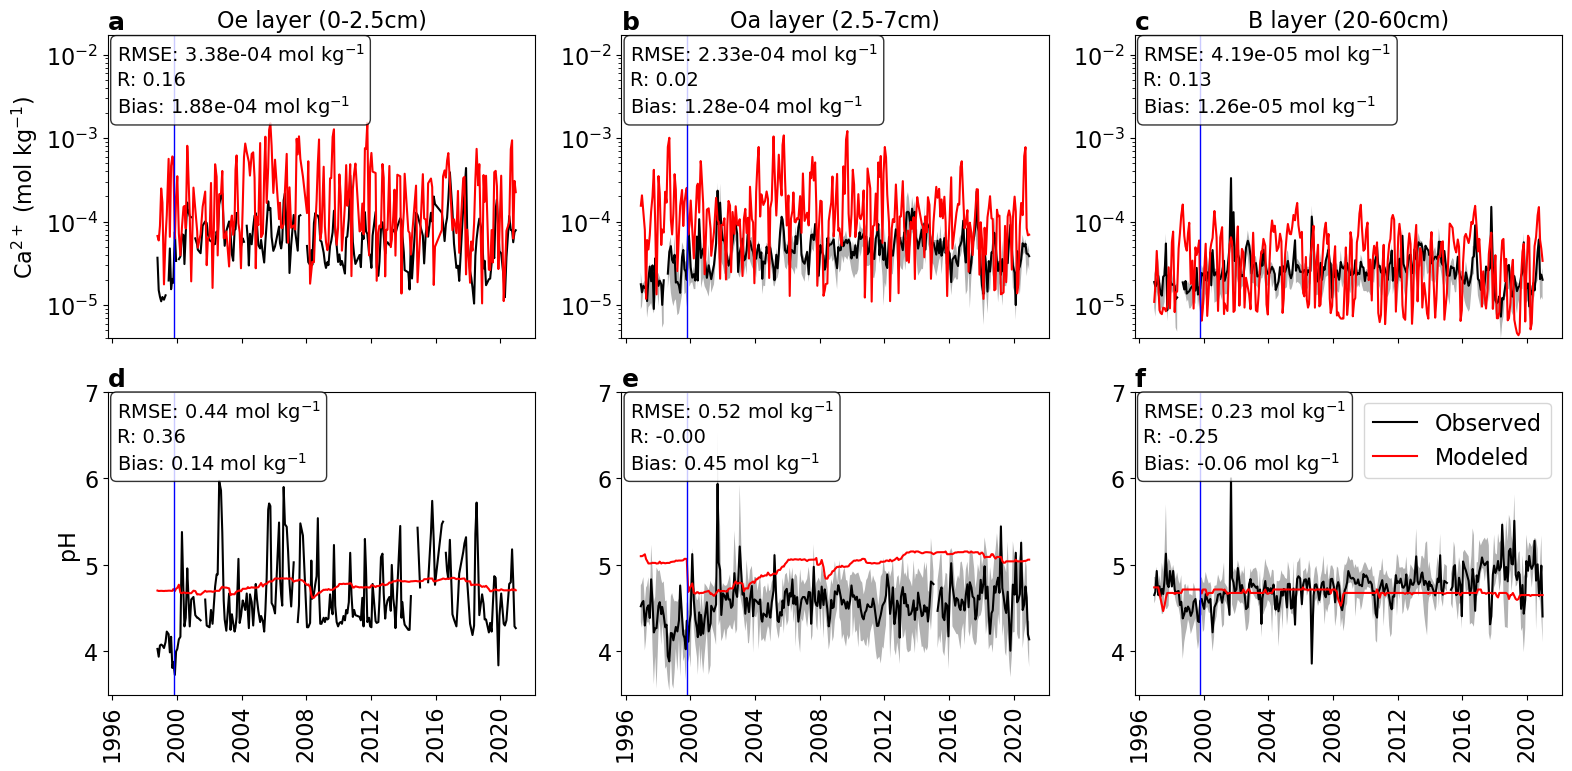

In [6]:
################################################
# Collect observed pore water cation concentration
################################################
# Layerwise soil pore water cation concentration
# Oe: 0-2.5cm (lacks std in 2020)
# Oa: 2.5-7cm
# B: 20-60cm
soil_pore_obs, soil_pore_obs_25, soil_pore_obs_75 = read_lysimeter()

# convert from g m-3 soil to mol/kg porewater
soil_pore_sim = {}
for i, (cation, mass_ca) in \
    enumerate(zip(['Ca2+','Mg2+','Na+','K+','Al3+'], 
                  [40, 24, 23, 29, 27])):
    soil_pore_sim[(cation, 'Oe')] = pd.Series( 
        ((hr[f'cation_vr_{i+1}'][:,:2,0] / hr['H2OSOI'][:,:2,0] / mass_ca / 1000) *
          np.array([1.75, 2.5-1.75]).reshape(1,-1)).sum(axis = 1) / 2.5, 
        index = tvec)
    soil_pore_sim[(cation, 'Oa')] = pd.Series( 
        ((hr[f'cation_vr_{i+1}'][:,1:3,0] / hr['H2OSOI'][:,1:3,0] / mass_ca / 1000) *
          np.array([4.51-2.5, 7-4.51]).reshape(1,-1)).sum(axis = 1) / (7-2.5), 
        index = tvec)
    soil_pore_sim[(cation, 'B')] = pd.Series( 
        ((hr[f'cation_vr_{i+1}'][:,4:6,0] / hr['H2OSOI'][:,4:6,0] / mass_ca / 1000) *
          np.array([28.91-20, 49.29-28.91]).reshape(1,-1)).sum(axis = 1) / (49.29-20), #, 60-49.29, (60-20)
        index = tvec)
soil_pore_sim[('pH', 'Oe')] = pd.Series( 
        (hr[f'soil_pH'][:,:2,0] * np.array([1.75, 2.5-1.75]).reshape(1,-1)).sum(axis = 1) / 2.5, 
        index = tvec)
soil_pore_sim[('pH', 'Oa')] = pd.Series( 
    (hr[f'soil_pH'][:,1:3,0] * np.array([4.51-2.5, 7-4.51]).reshape(1,-1)).sum(axis = 1) / (7-2.5), 
        index = tvec)
soil_pore_sim[('pH', 'B')] = pd.Series( 
    (hr[f'soil_pH'][:,4:6,0] * np.array([28.91-20, 49.29-28.91]).reshape(1,-1) # , 60-49.29
     ).sum(axis = 1) / (49.29-20), # (60-20), 
        index = tvec)
soil_pore_sim = pd.DataFrame(soil_pore_sim).stack()
soil_pore_sim.index = soil_pore_sim.index.reorder_levels([1, 0])
soil_pore_sim = soil_pore_sim.sort_index()


soil_pore_sim_ctrl = {}
for i, (cation, mass_ca) in \
    enumerate(zip(['Ca2+','Mg2+','Na+','K+','Al3+'], 
                  [40, 24, 23, 29, 27])):
    soil_pore_sim_ctrl[(cation, 'Oe')] = pd.Series( 
        ((hr_ctrl[f'cation_vr_{i+1}'][:,:2,0] / hr_ctrl['H2OSOI'][:,:2,0] / mass_ca / 1000) *
          np.array([1.75, 2.5-1.75]).reshape(1,-1)).sum(axis = 1) / 2.5, 
        index = tvec)
    soil_pore_sim_ctrl[(cation, 'Oa')] = pd.Series( 
        ((hr_ctrl[f'cation_vr_{i+1}'][:,1:3,0] / hr_ctrl['H2OSOI'][:,1:3,0] / mass_ca / 1000) *
          np.array([4.51-2.5, 7-4.51]).reshape(1,-1)).sum(axis = 1) / (7-2.5), 
        index = tvec)
    soil_pore_sim_ctrl[(cation, 'B')] = pd.Series( 
        ((hr_ctrl[f'cation_vr_{i+1}'][:,4:6,0] / hr_ctrl['H2OSOI'][:,4:6,0] / mass_ca / 1000) *
          np.array([28.91-20, 49.29-28.91]).reshape(1,-1)).sum(axis = 1) / (49.29-20), #, 60-49.29, (60-20)
        index = tvec)
soil_pore_sim_ctrl[('pH', 'Oe')] = pd.Series( 
        (hr_ctrl[f'soil_pH'][:,:2,0] * np.array([1.75, 2.5-1.75]).reshape(1,-1)).sum(axis = 1) / 2.5, 
        index = tvec)
soil_pore_sim_ctrl[('pH', 'Oa')] = pd.Series( 
    (hr_ctrl[f'soil_pH'][:,1:3,0] * np.array([4.51-2.5, 7-4.51]).reshape(1,-1)).sum(axis = 1) / (7-2.5), 
        index = tvec)
soil_pore_sim_ctrl[('pH', 'B')] = pd.Series( 
    (hr_ctrl[f'soil_pH'][:,4:6,0] * np.array([28.91-20, 49.29-28.91]).reshape(1,-1) # , 60-49.29
     ).sum(axis = 1) / (49.29-20), # (60-20), 
        index = tvec)
soil_pore_sim_ctrl = pd.DataFrame(soil_pore_sim_ctrl).stack()
soil_pore_sim_ctrl.index = soil_pore_sim_ctrl.index.reorder_levels([1, 0])
soil_pore_sim_ctrl = soil_pore_sim_ctrl.sort_index()


# Focus on pH and Ca2+ in the main text
unit_str = '$\\mathrm{{mol\\ kg^{{-1}}}}$'
fig, axes = plt.subplots(2, 3, figsize = (16, 8), sharex = True)
for i, (layer,depth) in enumerate(zip(['Oe', 'Oa', 'B'],['0-2.5cm','2.5-7cm','20-60cm'])):
    obs = soil_pore_obs.loc[layer, :]
    obs_25 = soil_pore_obs_25.loc[layer, :]
    obs_75 = soil_pore_obs_75.loc[layer, :]
    sim = soil_pore_sim.loc[layer, :]
    sim_ctrl = soil_pore_sim_ctrl.loc[layer, :]

    index = obs.index.intersection(obs_25.index).intersection(sim.index)
    obs = obs.loc[index, :]
    obs_25 = obs_25.loc[index, :]
    obs_75 = obs_75.loc[index, :]
    sim = sim.loc[index, :]
    sim_ctrl = sim_ctrl.loc[index, :]

    for j, (obs_ca, sim_ca, name) in enumerate(
        zip(['Ca2+','pH'],
            ['Ca2+','pH'], 
            ['Ca$^{2+}$','pH'])
    ):
        ax = axes[j,i]

        ax.plot(index, obs[obs_ca], '-k', label = 'Observed')
        ax.fill_between(
            index, obs_25[obs_ca], obs_75[obs_ca], 
            fc = 'k', alpha = 0.3
        )
        ax.plot(index, sim[sim_ca], '-r', label = 'Modeled')
        if j == 0:
            ax.set_title(f'{layer} layer ({depth})')

        ax.set_xlabel('')
        if np.mod(i, 3) == 0:
            if sim_ca != 'pH':
                ax.set_ylabel(f'{name} ({unit_str})')
            else:
                ax.set_ylabel('pH')
        if sim_ca != 'pH':
            ax.set_yscale('log')
            if sim_ca == 'Ca2+':
                ax.set_ylim([4e-6, 1.7e-2])
        else:
            ax.set_ylim([3.5,7])
        plt.setp(ax.get_xticklabels(), rotation = 90)

        h = ax.axvline(pd.Timestamp('1999-10-19'), color = 'b', ls = '-', lw = 1, alpha = 1)
        #ax.legend([h], ['Wollastonite\napplication'], loc = 'upper right')

        rmse_a = np.sqrt(np.nanmean((sim[sim_ca].values - obs[obs_ca])**2))
        corr_a = np.corrcoef(obs[obs_ca].values[~np.isnan(obs[obs_ca].values)],
                             sim[sim_ca].values[~np.isnan(obs[obs_ca].values)])[0, 1]
        bias_a = np.nanmean(sim[sim_ca].values - obs[obs_ca].values)
        if sim_ca != 'pH':
            ax.text(0.02, 0.98, f'RMSE: {rmse_a:.2e} {unit_str}\nR: {corr_a:.2f}\nBias: {bias_a:.2e} {unit_str}',
                    transform=ax.transAxes, va='top', fontsize=14,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        else:
            ax.text(0.02, 0.98, f'RMSE: {rmse_a:.2f} {unit_str}\nR: {corr_a:.2f}\nBias: {bias_a:.2f} {unit_str}',
                    transform=ax.transAxes, va='top', fontsize=14,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        ax.text(0., 1.02, ascii_lowercase[j*3+i], transform = ax.transAxes, fontweight='bold', fontsize=18)

ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'results', 'figures',
                         'validation_HBR_2.png'), dpi = 600., bbox_inches = 'tight')

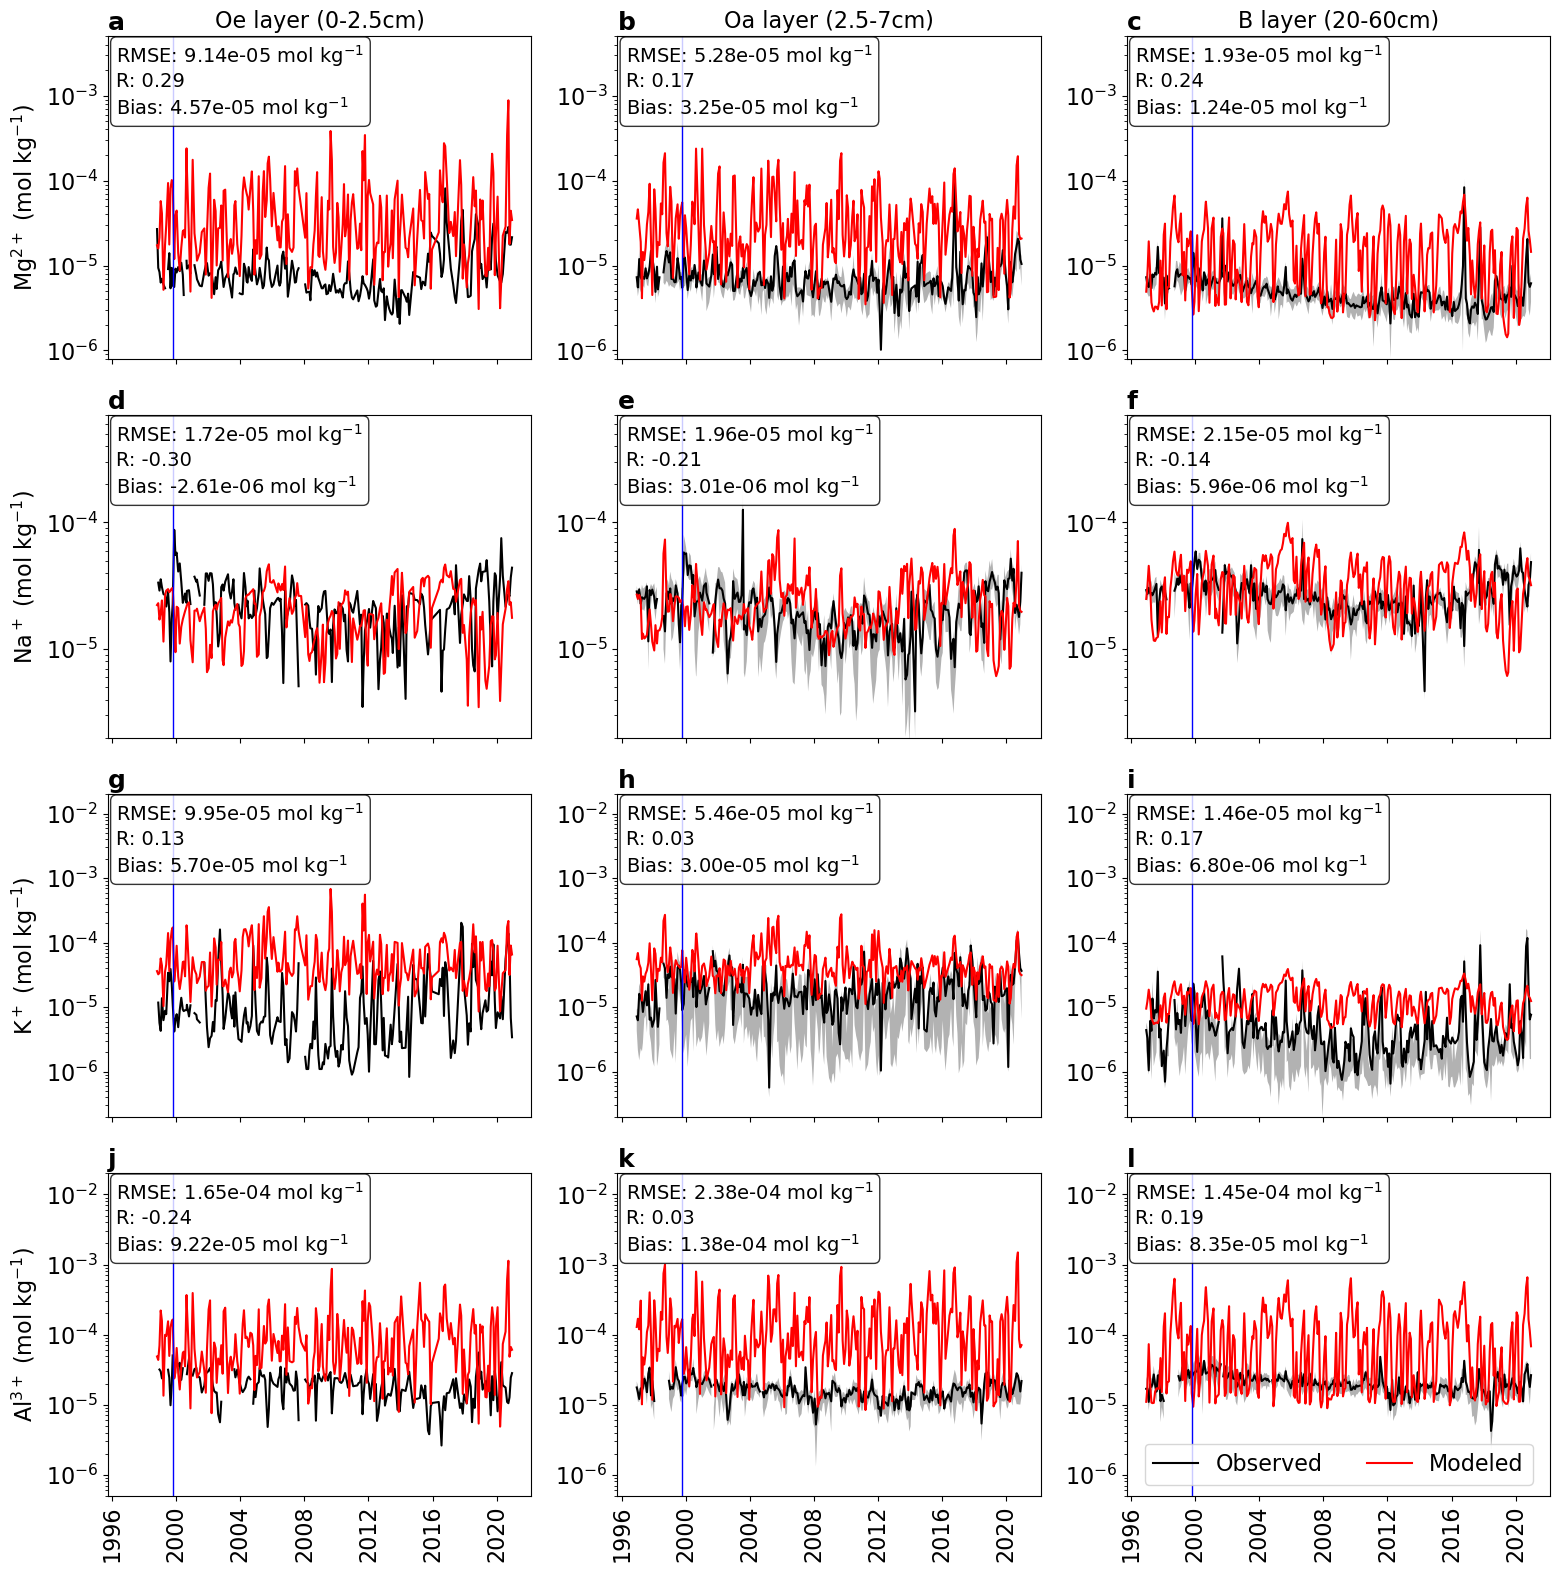

In [12]:
# Focus on Mg2+, Na+, K+, Al3+ in the SI
fig, axes = plt.subplots(4, 3, figsize = (16, 16), sharex = True)
for i, (layer,depth) in enumerate(zip(['Oe', 'Oa', 'B'],['0-2.5cm','2.5-7cm','20-60cm'])):
    obs = soil_pore_obs.loc[layer, :]
    obs_25 = soil_pore_obs_25.loc[layer, :]
    obs_75 = soil_pore_obs_75.loc[layer, :]
    sim = soil_pore_sim.loc[layer, :]
    sim_ctrl = soil_pore_sim_ctrl.loc[layer, :]

    index = obs.index.intersection(obs_25.index).intersection(sim.index)
    obs = obs.loc[index, :]
    obs_25 = obs_25.loc[index, :]
    obs_75 = obs_75.loc[index, :]
    sim = sim.loc[index, :]
    sim_ctrl = sim_ctrl.loc[index, :]

    for j, (obs_ca, sim_ca, name) in enumerate(
        zip(['Mg2+', 'Na+', 'K+', 'Alt'],
            ['Mg2+','Na+','K+','Al3+'], 
            ['Mg$^{2+}$','Na$^+$','K$^+$','Al$^{3+}$'])
    ):
        ax = axes[j,i]

        ax.plot(index, obs[obs_ca], '-k', label = 'Observed')
        ax.fill_between(
            index, obs_25[obs_ca], obs_75[obs_ca], 
            fc = 'k', alpha = 0.3
        )
        ax.plot(index, sim[sim_ca], '-r', label = 'Modeled')
        if j == 0:
            ax.set_title(f'{layer} layer ({depth})')

        ax.set_xlabel('')
        if np.mod(i, 3) == 0:
            if sim_ca != 'pH':
                ax.set_ylabel(f'{name} ({unit_str})')
            else:
                ax.set_ylabel('pH')
        if sim_ca != 'pH':
            ax.set_yscale('log')
            if sim_ca == 'Ca2+':
                ax.set_ylim([4e-6, 1.2e-2])
        else:
            ax.set_ylim([3.5,7])
        plt.setp(ax.get_xticklabels(), rotation = 90)

        h = ax.axvline(pd.Timestamp('1999-10-19'), color = 'b', ls = '-', lw = 1, alpha = 1)

        rmse_a = np.sqrt(np.nanmean((sim[sim_ca].values - obs[obs_ca])**2))
        corr_a = np.corrcoef(obs[obs_ca].values[~np.isnan(obs[obs_ca].values)],
                             sim[sim_ca].values[~np.isnan(obs[obs_ca].values)])[0, 1]
        bias_a = np.nanmean(sim[sim_ca].values - obs[obs_ca].values)
        if sim_ca != 'pH':
            ax.text(0.02, 0.98, f'RMSE: {rmse_a:.2e} {unit_str}\nR: {corr_a:.2f}\nBias: {bias_a:.2e} {unit_str}',
                    transform=ax.transAxes, va='top', fontsize=14,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        else:
            ax.text(0.02, 0.98, f'RMSE: {rmse_a:.2f} {unit_str}\nR: {corr_a:.2f}\nBias: {bias_a:.2f} {unit_str}',
                    transform=ax.transAxes, va='top', fontsize=14,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        ax.text(0., 1.02, ascii_lowercase[j*3+i], transform = ax.transAxes, fontweight='bold', fontsize=18)

        if sim_ca == 'Mg2+':
            ax.set_ylim([8e-7, 5e-3])
        elif sim_ca == 'Na+':
            ax.set_ylim([2e-6, 7e-4])
        elif sim_ca == 'K+':
            ax.set_ylim([2e-7, 2e-2])
        elif sim_ca == 'Al3+':
            ax.set_ylim([5e-7, 2e-2])

ax.legend(loc='lower center', ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'results', 'figures',
                         'validation_HBR_3.png'), dpi = 600., bbox_inches = 'tight')

In [8]:
################################################
# Validate on observed CEC contents
################################################
hsurf = xr.open_dataset(os.path.join(os.environ['E3SM_ROOT'], 'inputdata', 'lnd',
                                     'clm2', 'PTCLM', 'HBR', 'surfdata_erw_TOP_FMAX_UP.nc'))
cec_tot = hsurf['CEC_TOT'][:, 0, 0].values
hsurf.close()


cec_obs_mean, cec_obs_std = read_cec()

# calcium: convert from g m-3 soil to meq 100g-1 dry soil
soil_cec_sim = {}
for i, (cation, val_icat, mass_icat) in \
    enumerate(zip(['Ca2+','Mg2+','Na+','K+','Al3+'], 
                  [2, 2, 1, 1, 3],
                  [40, 24, 23, 29, 27])):

    soil_cec_sim[(cation, 'Oie')] = \
        (hr[f'cec_cation_vr_{i+1}'][:,:2,0].values * \
         np.array([1.75,2.5-1.75]).reshape(1,-1)).sum(axis = 1) * \
        1000 * val_icat / mass_icat / 10 / \
        (hr['bd_col'][:,:2,0].values * np.array([1.75,2.5-1.75]).reshape(1,-1)
        ).sum(axis = 1)

    soil_cec_sim[(cation, 'Oa')] = \
        (hr[f'cec_cation_vr_{i+1}'][:,1:3,0].values * \
         np.array([4.51-2.5, 7-4.51]).reshape(1,-1)).sum(axis = 1) * \
        1000 * val_icat / mass_icat / 10 / \
        (hr['bd_col'][:,1:3,0].values * np.array([4.51-2.5, 7-4.51]).reshape(1,-1)
        ).sum(axis = 1)

    soil_cec_sim[(cation, 'Min')] = \
        (hr[f'cec_cation_vr_{i+1}'][:,2:5,0].values * \
         np.array([9.06-7, 16.55-9.06, 17-16.55]).reshape(1,-1)).sum(axis = 1) * \
        1000 * val_icat / mass_icat / 10 / \
        (hr['bd_col'][:,2:5,0].values * np.array([9.06-7, 16.55-9.06, 17-16.55]).reshape(1,-1)
        ).sum(axis = 1)

soil_cec_sim[('H+', 'Oie')] = \
    (hr[f'cec_proton_vr'][:,:2,0].values * np.array([1.75,2.5-1.75]).reshape(1,-1)
    ).sum(axis = 1) * 1000 / 10 / \
    (hr['bd_col'][:,:2,0].values * np.array([1.75,2.5-1.75]).reshape(1,-1)
    ).sum(axis = 1)

soil_cec_sim[('H+', 'Oa')] = \
    (hr[f'cec_proton_vr'][:,1:3,0].values * np.array([4.51-2.5, 7-4.51]).reshape(1,-1)
    ).sum(axis = 1) * 1000 / 10 / \
    (hr['bd_col'][:,1:3,0].values * np.array([4.51-2.5, 7-4.51]).reshape(1,-1)
    ).sum(axis = 1)

soil_cec_sim[('H+', 'Min')] = \
    (hr[f'cec_proton_vr'][:,2:5,0].values * np.array([9.06-7, 16.55-9.06, 17-16.55]).reshape(1,-1)
    ).sum(axis = 1) * 1000 / 10 / \
    (hr['bd_col'][:,2:5,0].values * np.array([9.06-7, 16.55-9.06, 17-16.55]).reshape(1,-1)
    ).sum(axis = 1)


soil_cec_sim = pd.DataFrame(soil_cec_sim, index = tvec).resample('1Y').mean()
soil_cec_sim.index = soil_cec_sim.index.year
soil_cec_sim = soil_cec_sim.stack()
soil_cec_sim.index = soil_cec_sim.index.reorder_levels([1, 0])
soil_cec_sim = soil_cec_sim.sort_index()

/tmp/ipykernel_4164145/79919001.py:59: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  soil_cec_sim = pd.DataFrame(soil_cec_sim, index = tvec).resample('1Y').mean()
/tmp/ipykernel_4164145/79919001.py:61: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  soil_cec_sim = soil_cec_sim.stack()


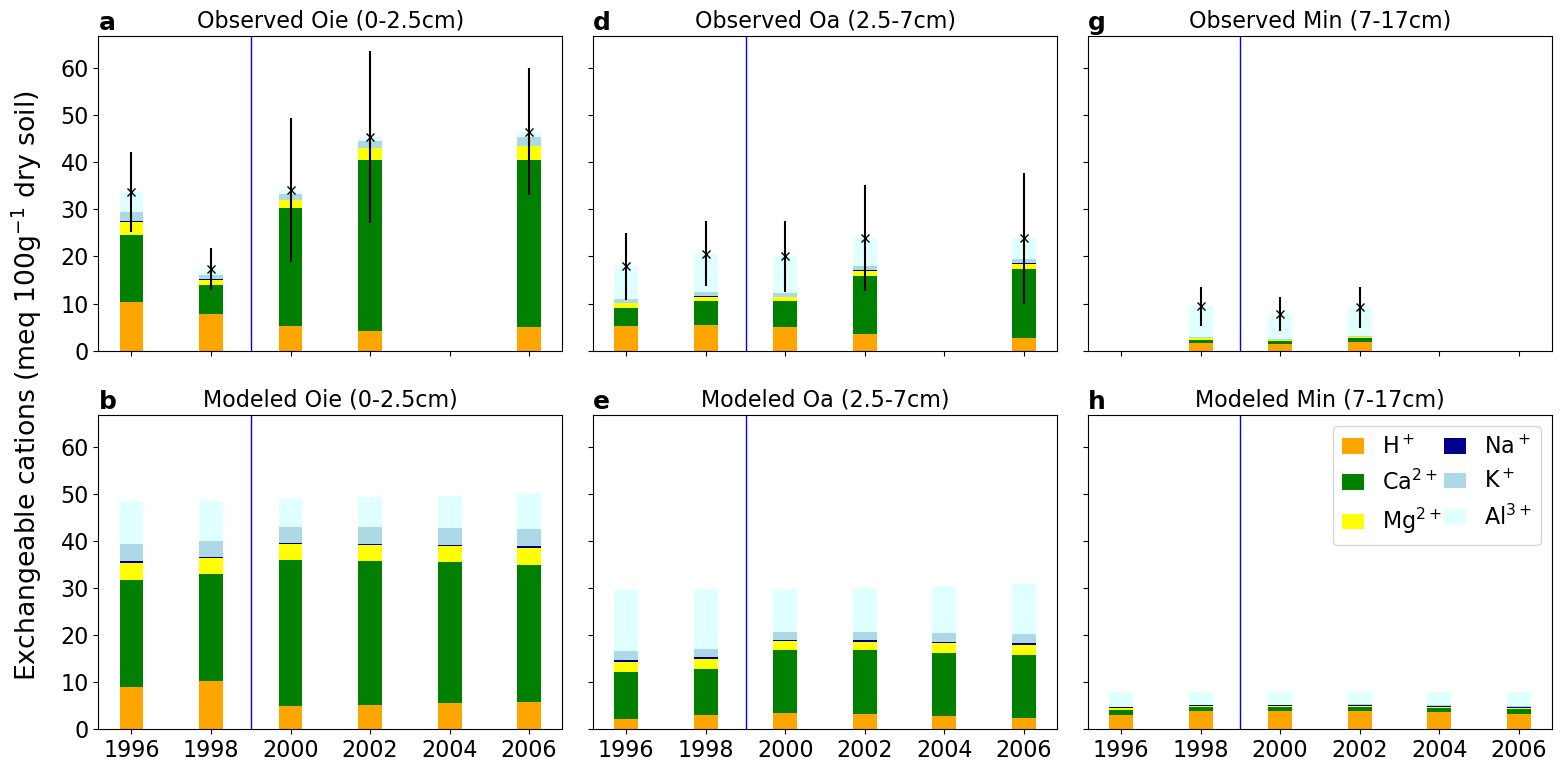

In [9]:
## Convert to beta values (fraction)
cec_obs = cec_obs_mean
cec_sim = soil_cec_sim.loc[soil_cec_sim.index.get_level_values(1).isin([1996,1998,2000,2002,2004,2006])] # / soil_cec_sim.sum(axis = 1).values.reshape(-1, 1)
# re-align the simulation's cation rank
cec_sim = cec_sim.loc[:, ['H+','Ca2+','Mg2+','Na+','K+','Al3+']]

color_list = ['#FFA500', '#008000', '#FFFF00', '#00008B', '#ADD8E6', '#E0FFFF']
name_list = ['H$^+$', 'Ca$^{2+}$', 'Mg$^{2+}$', 'Na$^+$', 'K$^+$', 'Al$^{3+}$']
handles = [Patch(facecolor=color, label=label) for color, label in zip(color_list, name_list)]

def plot_bar(df, ax, std = None):
    for j, x in enumerate(df.index):
        bottom = 0  # Starting bottom for stacking
        for col, color in zip(df.columns, color_list):
            value = df.loc[x, col]
            ax.bar(x, value, bottom=bottom, color=color, width=0.6)
            bottom += value
        if not std is None:
            ax.errorbar(x, bottom, std.loc[x], marker='x', color = 'k')

fig, axes = plt.subplots(2,3, figsize = (16, 8), sharex = True, sharey = True)
for i, (horizon,depth) in enumerate(zip(['Oie', 'Oa', 'Min'],['0-2.5cm','2.5-7cm','7-17cm'])):

    plot_bar( cec_obs.loc[horizon], axes[0,i], cec_obs_std.loc[horizon] )
    plot_bar( cec_sim.loc[horizon], axes[1,i] )

    axes[0,i].axvline(1999, color = 'b', ls = '-', lw = 1, alpha = 1)
    axes[1,i].axvline(1999, color = 'b', ls = '-', lw = 1, alpha = 1)

    # Place the legend outside the plot area (to the right)
    if i == 2:
        axes[1,i].legend(handles=handles, ncol = 2, handlelength = 1, 
                         columnspacing = 0.1)

    axes[1,i].set_xticks(cec_sim.loc[horizon].index)
    axes[0,i].set_title(f'Observed {horizon} ({depth})')
    axes[1,i].set_title(f'Modeled {horizon} ({depth})')
    axes[0,i].text(0., 1.02, ascii_lowercase[i*3+0], transform = axes[0,i].transAxes, fontweight='bold', fontsize=18)
    axes[1,i].text(0., 1.02, ascii_lowercase[i*3+1], transform = axes[1,i].transAxes, fontweight='bold', fontsize=18)
fig.supylabel('Exchangeable cations (meq 100g$^{-1}$ dry soil)')
plt.tight_layout()
plt.savefig(os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'results', 'figures',
                         'validation_HBR_4.png'), dpi = 600., bbox_inches = 'tight')

In [10]:
hr.close()
hr_ctrl.close()